# Project 1: Classification Exercise (Superviced Learning)

# Task

1.Import the necessary libraries

2.Load the Dataset

3.EDA

4.Split the Dataset

5.Initialize and train at least 3 supervised classification models

6.Make predictions

7.Evaluate the model with metrics suitable for classification

8.Write within your notebook at least 3 conclusions from the analysis

9.Your main goal is to attain an overall accuracy higher than 80%.



In [62]:
import torch
torch.cuda.is_available()

True

In [63]:
!unzip -o sf-crime.zip

Archive:  sf-crime.zip
  inflating: sampleSubmission.csv.zip  
  inflating: test.csv.zip            
  inflating: train.csv.zip           


In [64]:
import pandas as pd



In [65]:
!unzip -o train.csv.zip

Archive:  train.csv.zip
  inflating: train.csv               


In [66]:
!unzip -o test.csv.zip

Archive:  test.csv.zip
  inflating: test.csv                


In [67]:
from IPython.testing import test
train_dataset_filename = 'train.csv'
test_dataset_filename = 'test.csv'

In [68]:
import pandas as pd

# Unzip sf-crime.zip to get train.csv (assuming train.csv is inside sf-crime.zip)
# Note: Earlier attempts to unzip sf-crime.zip also failed, indicating a potential issue with the zip file itself.
# If this still fails, please ensure a valid sf-crime.zip or train.csv.zip is present.
!unzip -o sf-crime.zip

# Load the Dataset
crimes_df = pd.read_csv(train_dataset_filename).head(1000)
crimes_df

Archive:  sf-crime.zip
  inflating: sampleSubmission.csv.zip  
  inflating: test.csv.zip            
  inflating: train.csv.zip           


,Dates,Category,Descript,DayOfWeek,PdDistrict,Resolution,Address,X,Y
0,2015-05-13 23:53:00,WARRANTS,WARRANT ARREST,Wednesday,NORTHERN,"ARREST, BOOKED",OAK ST / LAGUNA ST,-122.425892,37.774599
1,2015-05-13 23:53:00,OTHER OFFENSES,TRAFFIC VIOLATION ARREST,Wednesday,NORTHERN,"ARREST, BOOKED",OAK ST / LAGUNA ST,-122.425892,37.774599
2,2015-05-13 23:33:00,OTHER OFFENSES,TRAFFIC VIOLATION ARREST,Wednesday,NORTHERN,"ARREST, BOOKED",VANNESS AV / GREENWICH ST,-122.424363,37.800414
3,2015-05-13 23:30:00,LARCENY/THEFT,GRAND THEFT FROM LOCKED AUTO,Wednesday,NORTHERN,NONE,1500 Block of LOMBARD ST,-122.426995,37.800873
4,2015-05-13 23:30:00,LARCENY/THEFT,GRAND THEFT FROM LOCKED AUTO,Wednesday,PARK,NONE,100 Block of BRODERICK ST,-122.438738,37.771541
...,...,...,...,...,...,...,...,...,...
995,2015-05-11 11:00:00,FRAUD,FRAUDULENT CREDIT APPLICATION,Monday,MISSION,NONE,400 Block of DOLORES ST,-122.426341,37.762579
996,2015-05-11 11:00:00,FRAUD,"CREDIT CARD, THEFT BY USE OF",Monday,MISSION,NONE,400 Block of DOLORES ST,-122.426341,37.762579
997,2015-05-11 11:00:00,LARCENY/THEFT,PETTY THEFT OF PROPERTY,Monday,RICHMOND,NONE,3200 Block of BALBOA ST,-122.493588,37.775941
998,2015-05-11 11:00:00,MISSING PERSON,MISSING JUVENILE,Monday,INGLESIDE,NONE,200 Block of CAYUGA AV,-122.433422,37.730390


In [69]:
crimes_df = pd.read_csv(test_dataset_filename)
crimes_df

,Id,Dates,DayOfWeek,PdDistrict,Address,X,Y
0,0,2015-05-10 23:59:00,Sunday,BAYVIEW,2000 Block of THOMAS AV,-122.399588,37.735051
1,1,2015-05-10 23:51:00,Sunday,BAYVIEW,3RD ST / REVERE AV,-122.391523,37.732432
2,2,2015-05-10 23:50:00,Sunday,NORTHERN,2000 Block of GOUGH ST,-122.426002,37.792212
3,3,2015-05-10 23:45:00,Sunday,INGLESIDE,4700 Block of MISSION ST,-122.437394,37.721412
4,4,2015-05-10 23:45:00,Sunday,INGLESIDE,4700 Block of MISSION ST,-122.437394,37.721412
...,...,...,...,...,...,...,...
884257,884257,2003-01-01 00:01:00,Wednesday,MISSION,2600 Block of BRYANT ST,-122.408983,37.751987
884258,884258,2003-01-01 00:01:00,Wednesday,NORTHERN,1900 Block of WASHINGTON ST,-122.425342,37.792681
884259,884259,2003-01-01 00:01:00,Wednesday,INGLESIDE,5500 Block of MISSION ST,-122.445418,37.712075
884260,884260,2003-01-01 00:01:00,Wednesday,BAYVIEW,1500 Block of HUDSON AV,-122.387394,37.739479


## Exploratory Data Analysis (EDA)

In [70]:
crimes_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 884262 entries, 0 to 884261
Data columns (total 7 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Id          884262 non-null  int64  
 1   Dates       884262 non-null  object 
 2   DayOfWeek   884262 non-null  object 
 3   PdDistrict  884262 non-null  object 
 4   Address     884262 non-null  object 
 5   X           884262 non-null  float64
 6   Y           884262 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 47.2+ MB


In [71]:
crimes_df.isnull().sum()

,0
Id,0
Dates,0
DayOfWeek,0
PdDistrict,0
Address,0
X,0
Y,0


In [72]:
(crimes_df.describe())

,Id,X,Y
count,884262.000000,884262.000000,884262.000000
mean,442130.500000,-122.422693,37.771476
std,255264.596206,0.030985,0.484824
min,0.000000,-122.513642,37.707879
25%,221065.250000,-122.433069,37.752374
50%,442130.500000,-122.416517,37.775421
75%,663195.750000,-122.406959,37.784353
max,884261.000000,-120.500000,90.000000


In [73]:
import pandas as pd

# Re-load train.csv to ensure 'Category' and 'Resolution' columns are present
# This assumes 'train_dataset_filename' is defined and points to 'train.csv'
crimes_df = pd.read_csv(train_dataset_filename).sample(10000)

print('\n--- Unique Values and Counts for Categorical Columns ---')

for col in ['Category', 'DayOfWeek', 'PdDistrict', 'Resolution']:
    print(f'\nUnique values in {col}:')
    print(crimes_df[col].value_counts())


--- Unique Values and Counts for Categorical Columns ---

Unique values in Category:
Category
LARCENY/THEFT                  1982
OTHER OFFENSES                 1431
NON-CRIMINAL                   1096
ASSAULT                         881
DRUG/NARCOTIC                   613
VEHICLE THEFT                   562
VANDALISM                       560
WARRANTS                        447
BURGLARY                        425
SUSPICIOUS OCC                  369
MISSING PERSON                  290
ROBBERY                         241
FRAUD                           170
FORGERY/COUNTERFEITING          125
SECONDARY CODES                 116
WEAPON LAWS                     108
TRESPASS                         88
PROSTITUTION                     83
STOLEN PROPERTY                  59
DISORDERLY CONDUCT               50
SEX OFFENSES FORCIBLE            46
DRUNKENNESS                      45
RECOVERED VEHICLE                42
DRIVING UNDER THE INFLUENCE      29
KIDNAPPING                       29
LIQUO

### Date Feature Engineering

Convertir la columna 'Fechas' en objetos de fecha y hora y extraer características útiles basadas en el tiempo.

In [ ]:
/Users/oscarmartinez/Desktop/Alcatrazcrime.ipynb

In [74]:
# Convertir la columna 'Fechas' en objetos de fecha y hora.
crimes_df['Dates'] = pd.to_datetime(crimes_df['Dates'])


In [75]:
# Extraer características basadas en el tiempo
crimes_df['Year'] = crimes_df['Dates'].dt.year
crimes_df['Month'] = crimes_df['Dates'].dt.month
crimes_df['Day'] = crimes_df['Dates'].dt.day
crimes_df['Hour'] = crimes_df['Dates'].dt.hour
crimes_df['Minute'] = crimes_df['Dates'].dt.minute
crimes_df['DayOfWeekNum'] = crimes_df['Dates'].dt.dayofweek # Monday=0, Sunday=6

display(crimes_df.head())
crimes_df.info()

,Dates,Category,Descript,DayOfWeek,PdDistrict,Resolution,Address,X,Y,Year,Month,Day,Hour,Minute,DayOfWeekNum
698385,2005-06-18 10:30:00,MISSING PERSON,FOUND PERSON,Saturday,TARAVAL,NONE,0 Block of LOMITA AV,-122.473000,37.757545,2005,6,18,10,30,5
403875,2009-09-06 15:03:00,DRUG/NARCOTIC,POSSESSION OF MARIJUANA FOR SALES,Sunday,MISSION,"ARREST, BOOKED",500 Block of DOLORES ST,-122.426153,37.760619,2009,9,6,15,3,6
839398,2003-07-09 09:30:00,OTHER OFFENSES,VIOLATION OF RESTRAINING ORDER,Wednesday,BAYVIEW,NONE,0 Block of MIDDLE POINT RD,-122.379454,37.737223,2003,7,9,9,30,2
68691,2014-06-15 09:00:00,VANDALISM,"MALICIOUS MISCHIEF, VANDALISM OF VEHICLES",Sunday,SOUTHERN,NONE,200 Block of KING ST,-122.393111,37.777310,2014,6,15,9,0,6
749126,2004-09-19 14:00:00,NON-CRIMINAL,LOST PROPERTY,Sunday,NORTHERN,NONE,FILLMORE ST / BROADWAY ST,-122.434921,37.794264,2004,9,19,14,0,6


<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 698385 to 296579
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Dates         10000 non-null  datetime64[ns]
 1   Category      10000 non-null  object        
 2   Descript      10000 non-null  object        
 3   DayOfWeek     10000 non-null  object        
 4   PdDistrict    10000 non-null  object        
 5   Resolution    10000 non-null  object        
 6   Address       10000 non-null  object        
 7   X             10000 non-null  float64       
 8   Y             10000 non-null  float64       
 9   Year          10000 non-null  int32         
 10  Month         10000 non-null  int32         
 11  Day           10000 non-null  int32         
 12  Hour          10000 non-null  int32         
 13  Minute        10000 non-null  int32         
 14  DayOfWeekNum  10000 non-null  int32         
dtypes: datetime64[ns](1), float64(2), i

### Data Visualization: Distributions

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns

In [77]:
# Establecer estilo para los gráficos
sns.set_style('whitegrid')

/tmp/ipykernel_33301/3321529813.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Category', data=crimes_df, order=crimes_df['Category'].value_counts().index, palette='viridis')


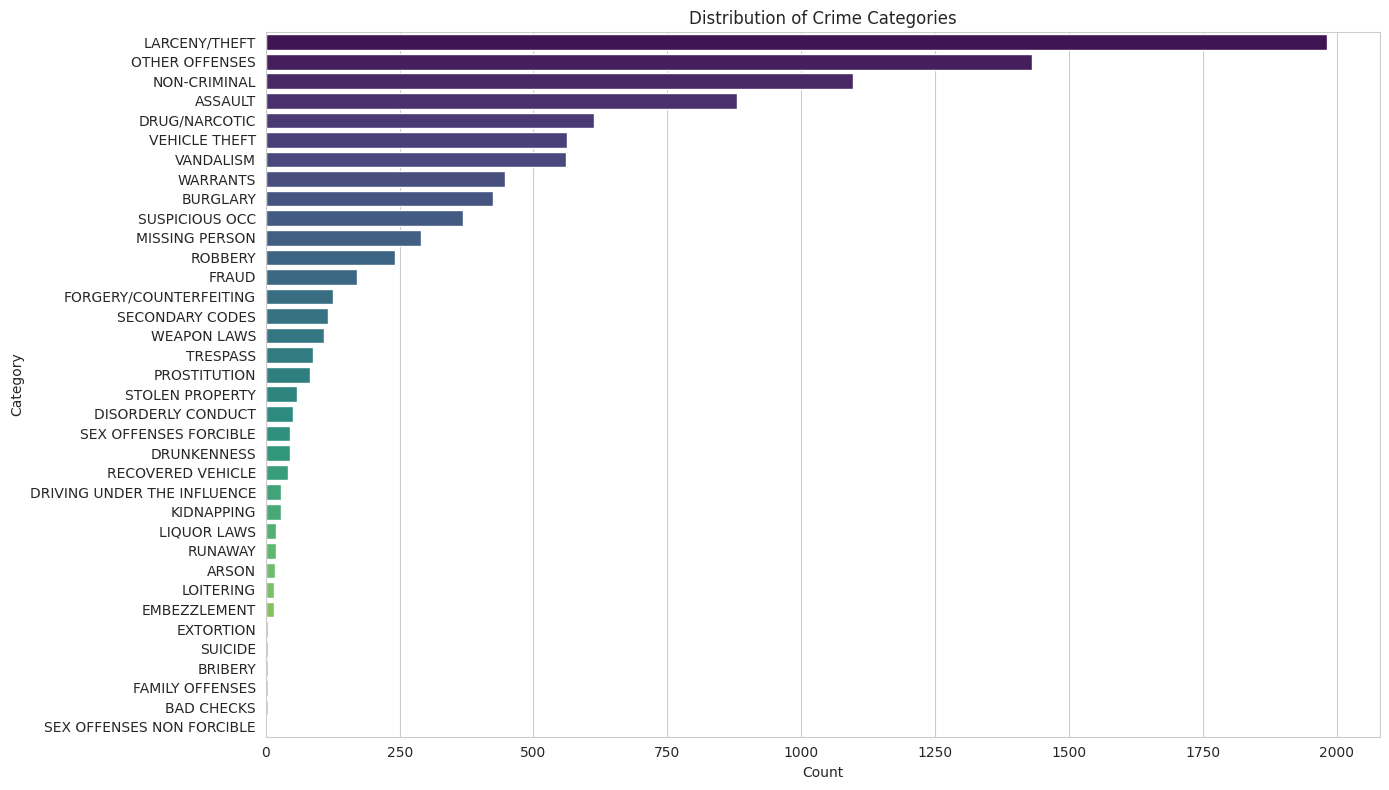

In [78]:
# Distribucion de categoria por crimenes
plt.figure(figsize=(14, 8))
sns.countplot(y='Category', data=crimes_df, order=crimes_df['Category'].value_counts().index, palette='viridis')
plt.title('Distribution of Crime Categories')
plt.xlabel('Count')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

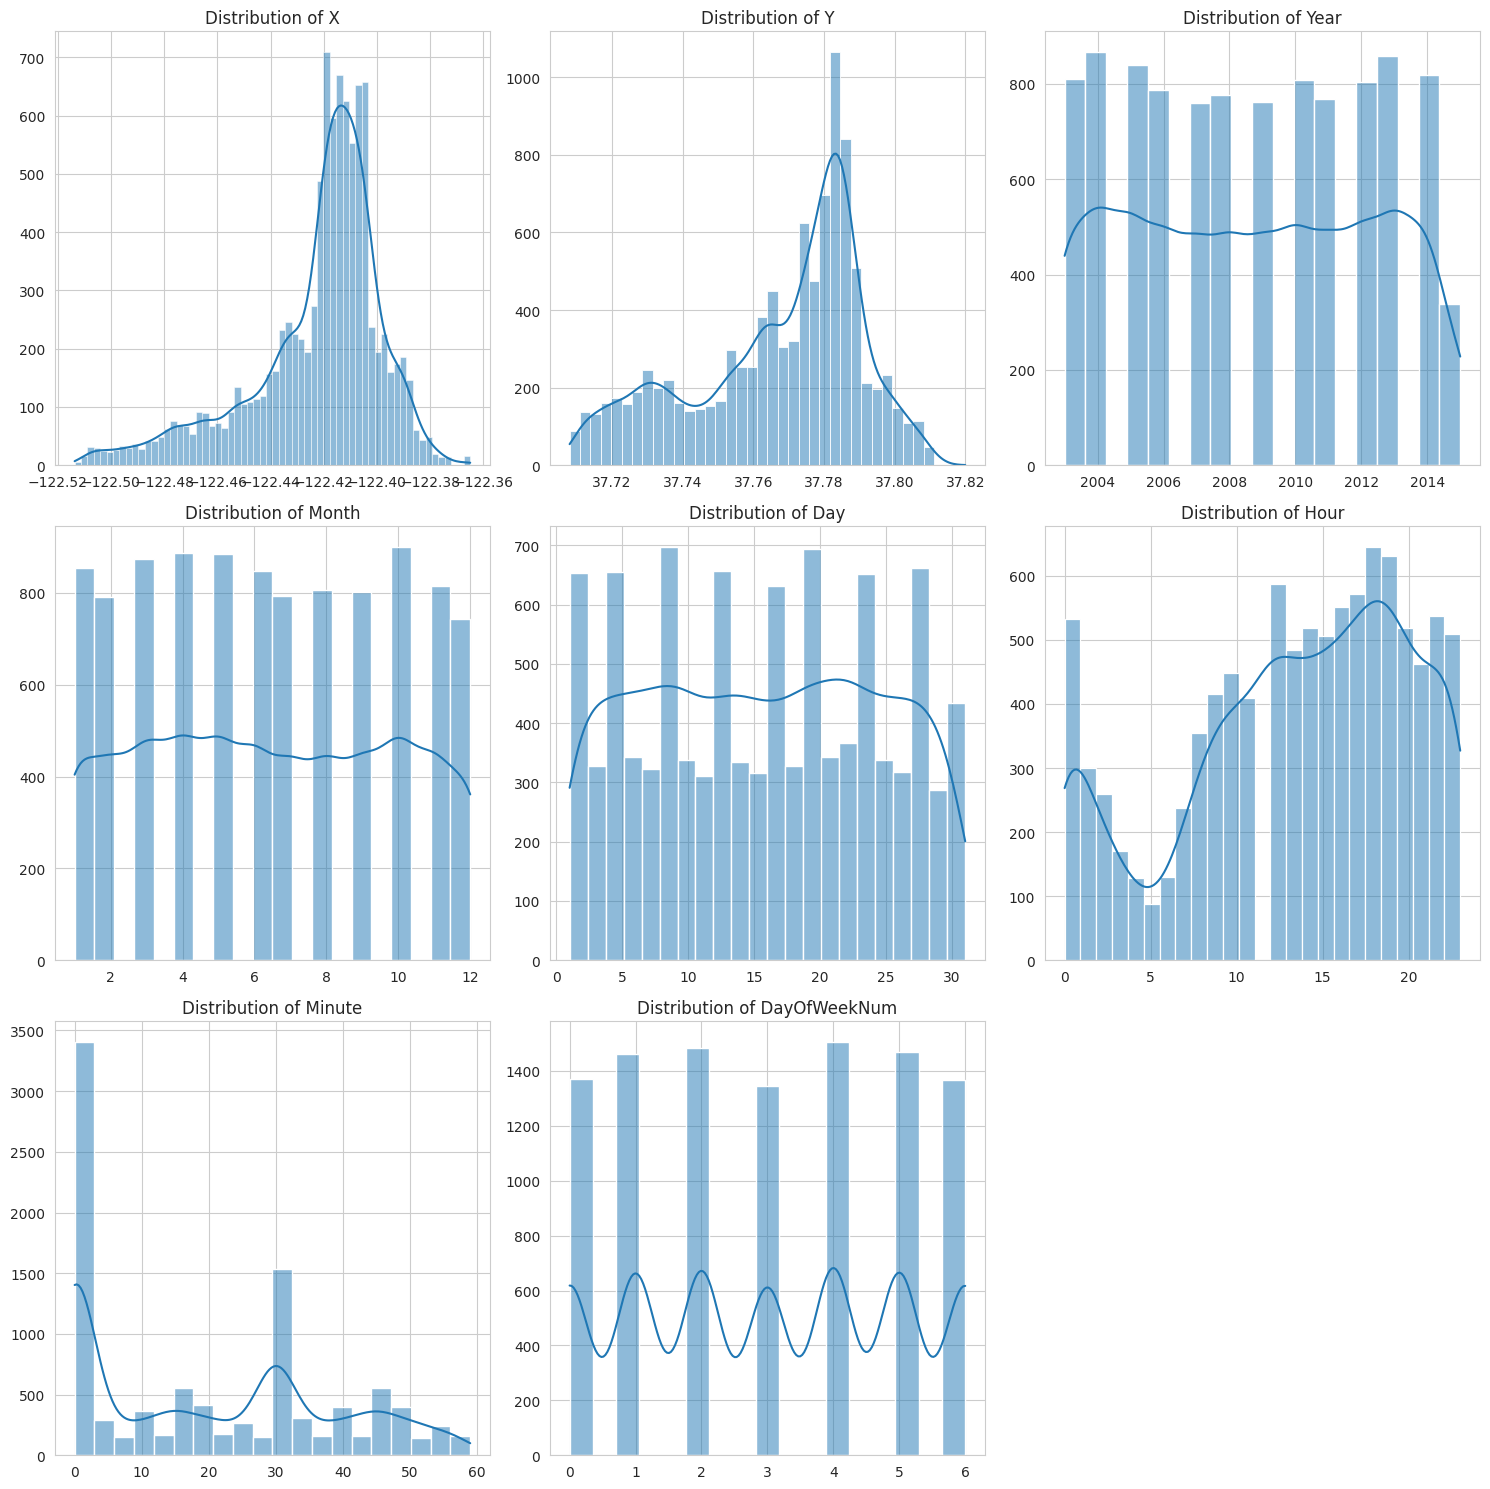

In [79]:
numeric_cols = ['X', 'Y', 'Year', 'Month', 'Day', 'Hour', 'Minute', 'DayOfWeekNum']

# Ajusta nrows y ncols según el número de columnas numéricas.
num_plots = len(numeric_cols)
nrows = (num_plots + 2) // 3 # Calcular las filas necesarias para 3 columnas por fila
ncols = 3 # Establece 3 columnas

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 5 * nrows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(crimes_df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

# Ocultar cualquier subtrama no utilizada
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

/tmp/ipykernel_33301/2102985279.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='DayOfWeek', data=crimes_df, order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'], palette='mako')


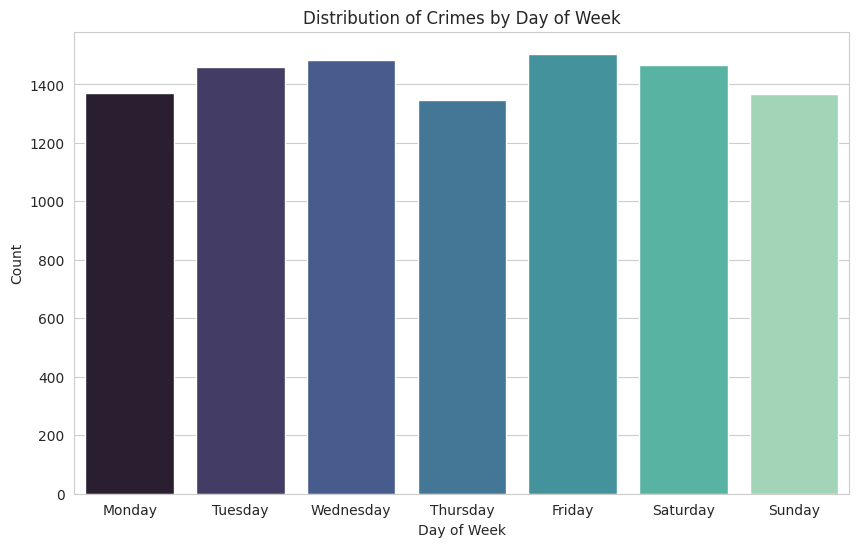

In [80]:
# Distribución del día de la semana
plt.figure(figsize=(10, 6))
sns.countplot(x='DayOfWeek', data=crimes_df, order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'], palette='mako')
plt.title('Distribution of Crimes by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Count')
plt.show()

/tmp/ipykernel_33301/3352478789.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='PdDistrict', data=crimes_df, order=crimes_df['PdDistrict'].value_counts().index, palette='crest')


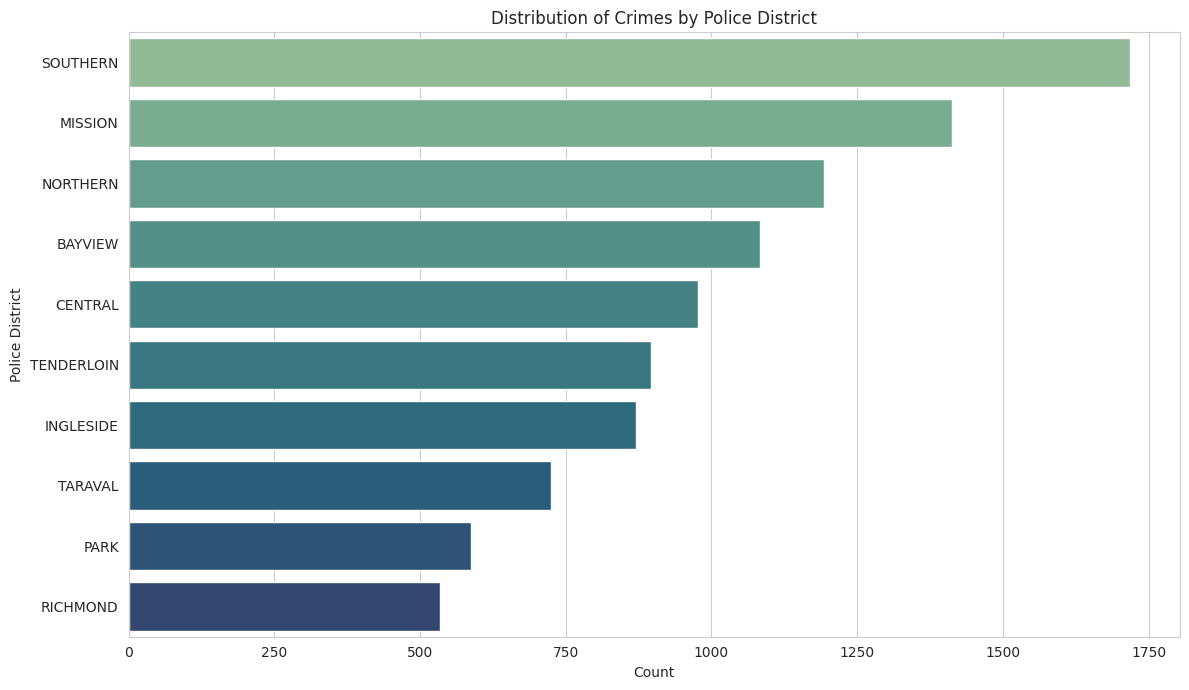

In [81]:
# Distribución de los distritos policiales
plt.figure(figsize=(12, 7))
sns.countplot(y='PdDistrict', data=crimes_df, order=crimes_df['PdDistrict'].value_counts().index, palette='crest')
plt.title('Distribution of Crimes by Police District')
plt.xlabel('Count')
plt.ylabel('Police District')
plt.tight_layout()
plt.show()

/tmp/ipykernel_33301/1063890832.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Resolution', data=crimes_df, order=crimes_df['Resolution'].value_counts().index, palette='rocket')


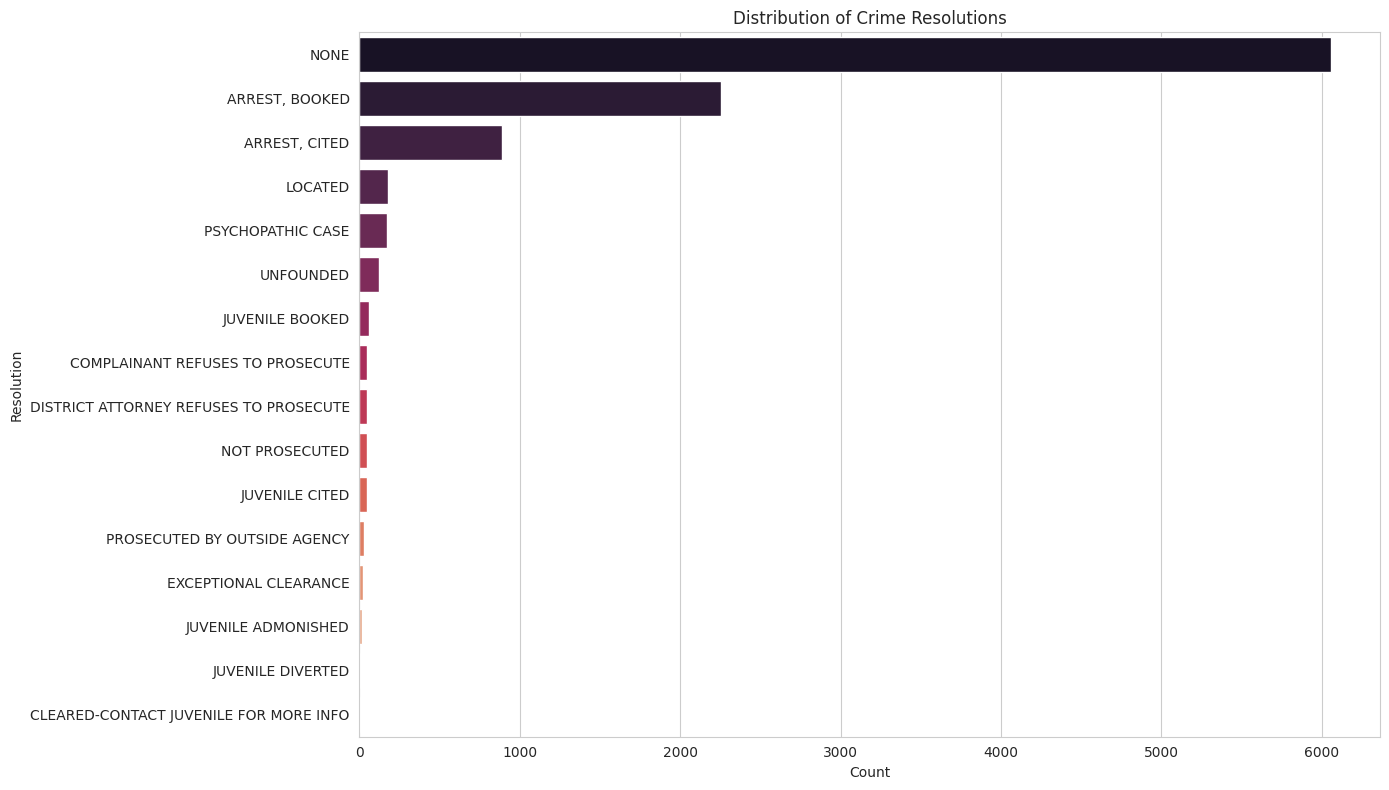

In [82]:
# Distribución de Resolución
plt.figure(figsize=(14, 8))
sns.countplot(y='Resolution', data=crimes_df, order=crimes_df['Resolution'].value_counts().index, palette='rocket')
plt.title('Distribution of Crime Resolutions')
plt.xlabel('Count')
plt.ylabel('Resolution')
plt.tight_layout()
plt.show()

/tmp/ipykernel_33301/2133533398.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Hour', data=crimes_df, palette='flare')


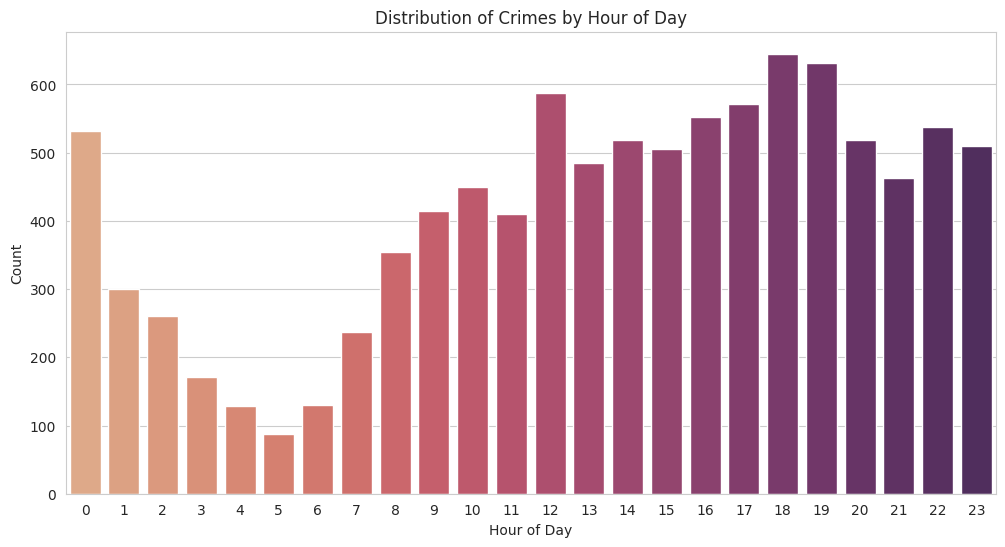

In [83]:
# Distribución de delitos por hora
plt.figure(figsize=(12, 6))
sns.countplot(x='Hour', data=crimes_df, palette='flare')
plt.title('Distribution of Crimes by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Count')
plt.show()

/tmp/ipykernel_33301/2328569916.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Month', data=crimes_df, palette='magma')


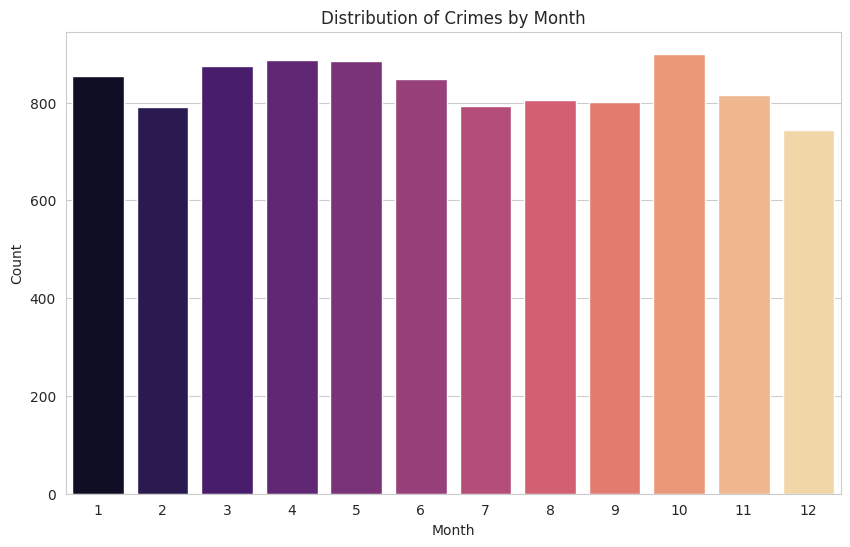

In [84]:
# Distribución de los delitos por mes
plt.figure(figsize=(10, 6))
sns.countplot(x='Month', data=crimes_df, palette='magma')
plt.title('Distribution of Crimes by Month')
plt.xlabel('Month')
plt.ylabel('Count')
plt.show()

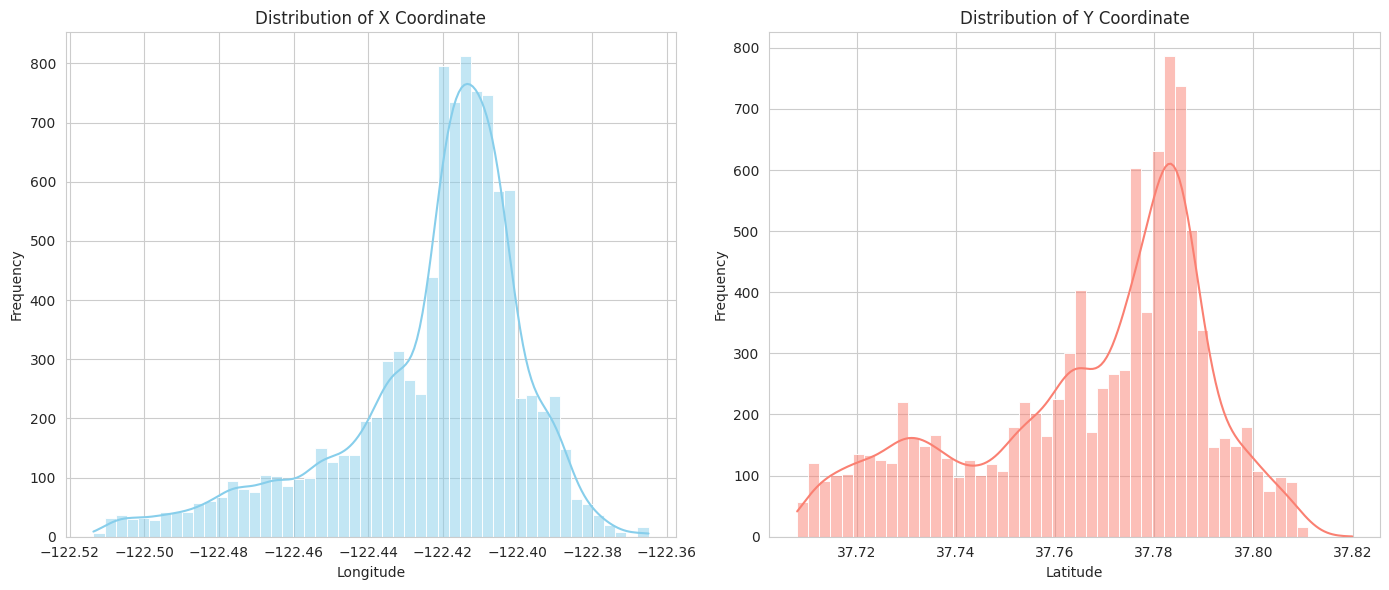

In [85]:
# Histogramas para coordenadas X e Y (Distribución geográfica)
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(crimes_df['X'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of X Coordinate')
plt.xlabel('Longitude')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.histplot(crimes_df['Y'], bins=50, kde=True, color='salmon')
plt.title('Distribution of Y Coordinate')
plt.xlabel('Latitude')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

## Split the Dataset

In [86]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [87]:
# Define el target variable (y) y features (X)
y = crimes_df['Category']

# Eliminar columnas que no sean características o que sean redundantes después de la ingeniería de características.
X = crimes_df.drop(columns=['Category', 'Dates', 'Descript', 'Resolution', 'Address'])

# Identificar  categorical and numerical features
categorical_features = ['DayOfWeek', 'PdDistrict']
numerical_features = ['X', 'Y', 'Year', 'Month', 'Day', 'Hour', 'Minute', 'DayOfWeekNum']

# Crea un transformador de columnas para la codificación one-hot de características categóricas # y para el paso de características numéricas.
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numerical_features)
    ])

# Aplicar preprocesamiento a X
X_processed = preprocessor.fit_transform(X)

# Codificar la variable de destino
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Dividir el conjunto de datos en conjuntos de entrenamiento y prueba.
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# Mostrar la correspondencia entre las categorías codificadas y sus nombres originales.
print('\nCategory Encoding Map:')
for i, category in enumerate(label_encoder.classes_):
    print(f"{i}: {category}")

X_train shape: (8000, 25)
X_test shape: (2000, 25)
y_train shape: (8000,)
y_test shape: (2000,)

Category Encoding Map:
0: ARSON
1: ASSAULT
2: BAD CHECKS
3: BRIBERY
4: BURGLARY
5: DISORDERLY CONDUCT
6: DRIVING UNDER THE INFLUENCE
7: DRUG/NARCOTIC
8: DRUNKENNESS
9: EMBEZZLEMENT
10: EXTORTION
11: FAMILY OFFENSES
12: FORGERY/COUNTERFEITING
13: FRAUD
14: KIDNAPPING
15: LARCENY/THEFT
16: LIQUOR LAWS
17: LOITERING
18: MISSING PERSON
19: NON-CRIMINAL
20: OTHER OFFENSES
21: PROSTITUTION
22: RECOVERED VEHICLE
23: ROBBERY
24: RUNAWAY
25: SECONDARY CODES
26: SEX OFFENSES FORCIBLE
27: SEX OFFENSES NON FORCIBLE
28: STOLEN PROPERTY
29: SUICIDE
30: SUSPICIOUS OCC
31: TRESPASS
32: VANDALISM
33: VEHICLE THEFT
34: WARRANTS
35: WEAPON LAWS


In [88]:
X_train, X_test



(array([[ 1.,  0.,  0., ..., 18., 25.,  4.],
        [ 0.,  0.,  1., ..., 16.,  0.,  5.],
        [ 0.,  1.,  0., ..., 12.,  0.,  0.],
        ...,
        [ 0.,  0.,  0., ...,  4.,  0.,  1.],
        [ 0.,  1.,  0., ..., 20., 45.,  0.],
        [ 1.,  0.,  0., ..., 19.,  0.,  4.]]),
 array([[ 0.,  0.,  1., ...,  6., 40.,  5.],
        [ 0.,  1.,  0., ..., 14., 15.,  0.],
        [ 0.,  0.,  0., ..., 12., 52.,  1.],
        ...,
        [ 1.,  0.,  0., ..., 18.,  0.,  4.],
        [ 1.,  0.,  0., ..., 18., 45.,  4.],
        [ 0.,  0.,  0., ..., 16.,  0.,  1.]]))

In [89]:
y_train, y_test

(array([19,  4, 15, ..., 15, 13, 33]), array([20,  1,  7, ..., 15,  1, 33]))

In [90]:
from sklearn.preprocessing import StandardScaler

# Scale features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and Train Supervised Classification Models

# LOGISTIC REGRESSION

In [91]:
from sklearn.linear_model import LogisticRegression

# Inicializacion Logistic Regression classifier
lr_model = LogisticRegression(max_iter=10000)
lr_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=10000)

In [92]:
y_pred_lr = lr_model.predict(X_test_scaled)
y_pred_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

In [100]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [94]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)

In [98]:
print("\nModel Accuracy:", accuracy_lr)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_lr,
    # target_names=label_encoder.classes_
))


Model Accuracy: 0.2255

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         4
           1       0.12      0.02      0.03       176
           2       0.00      0.00      0.00         1
           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00        85
           5       0.00      0.00      0.00        10
           6       0.00      0.00      0.00         6
           7       0.20      0.20      0.20       123
           8       0.00      0.00      0.00         9
           9       0.00      0.00      0.00         3
          10       0.00      0.00      0.00         1
          11       0.00      0.00      0.00         1
          12       0.00      0.00      0.00        25
          13       0.00      0.00      0.00        34
          14       0.00      0.00      0.00         6
          15       0.26      0.76      0.39       396
          16       0.00      0.00

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


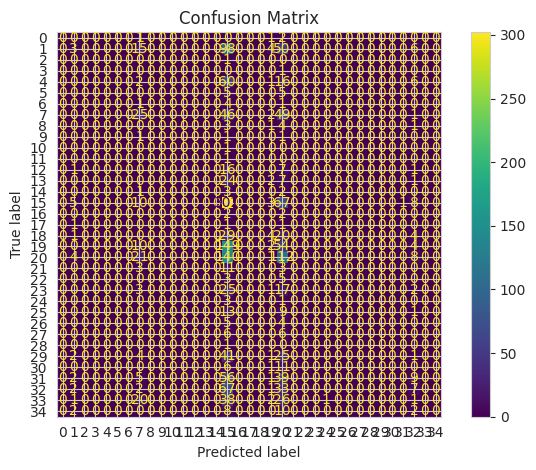

In [102]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_lr)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    # display_labels=label_encoder.classes_
)

disp.plot()
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

In [103]:
# Import necessary classification models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# DECISION TREE

In [104]:
# Train Decision Tree Classifier
print("Training Decision Tree Classifier...")
decision_tree_model = DecisionTreeClassifier()
decision_tree_model.fit(X_train_scaled, y_train)
print("Decision Tree Classifier training complete.")

Training Decision Tree Classifier...
Decision Tree Classifier training complete.


In [105]:
# Inicializacion Decision Tree classifier
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train_scaled, y_train)

DecisionTreeClassifier()

In [106]:
y_pred_dt = dt_model.predict(X_test_scaled)

In [107]:
accuracy_dt = accuracy_score(y_test, y_pred_dt)

In [109]:
print("\nModel Accuracy:", accuracy_dt)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_dt,
    # target_names=label_encoder.classes_
))


Model Accuracy: 0.1325

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         4
           1       0.08      0.09      0.08       176
           2       0.00      0.00      0.00         1
           3       0.00      0.00      0.00         1
           4       0.09      0.09      0.09        85
           5       0.00      0.00      0.00        10
           6       0.00      0.00      0.00         6
           7       0.12      0.14      0.13       123
           8       0.00      0.00      0.00         9
           9       0.00      0.00      0.00         3
          10       0.00      0.00      0.00         1
          11       0.00      0.00      0.00         1
          12       0.00      0.00      0.00        25
          13       0.00      0.00      0.00        34
          14       0.00      0.00      0.00         6
          15       0.29      0.29      0.29       396
          16       0.00      0.00

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


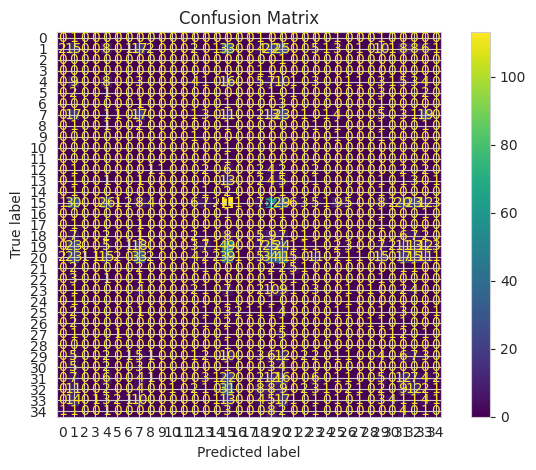

In [111]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_dt)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    # display_labels=label_encoder.classes_
)

disp.plot()
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

# RANDOM FOREST

In [112]:
from sklearn.ensemble import RandomForestClassifier

In [113]:
# Initialize and train Random Forest classifier
rf_model = RandomForestClassifier()
rf_model.fit(X_train_scaled, y_train)

RandomForestClassifier()

In [114]:
# Predicciones usando el modelo RANDOM FOREST
y_pred_rf = rf_model.predict(X_test_scaled)

In [116]:
# Calculate accuracy for Random Forest
from sklearn.metrics import accuracy_score, classification_report

accuracy_rf = accuracy_score(y_test, y_pred_rf)
print("\nRandom Forest Model Accuracy:", accuracy_rf)

print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf)) # target_names=label_encoder.classes


Random Forest Model Accuracy: 0.2345

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         4
           1       0.11      0.10      0.10       176
           2       0.00      0.00      0.00         1
           3       0.00      0.00      0.00         1
           4       0.06      0.01      0.02        85
           5       0.00      0.00      0.00        10
           6       0.00      0.00      0.00         6
           7       0.23      0.25      0.24       123
           8       0.00      0.00      0.00         9
           9       0.00      0.00      0.00         3
          10       0.00      0.00      0.00         1
          11       0.00      0.00      0.00         1
          12       0.00      0.00      0.00        25
          13       0.00      0.00      0.00        34
          14       0.00      0.00      0.00         6
          15       0.31      0.64      0.42       396
     

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


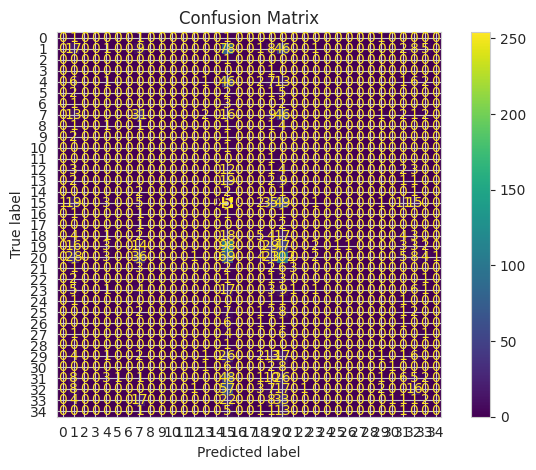

In [118]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    # display_labels=label_encoder.classes_
)

disp.plot()
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

## SUPPORT VECTOR MACHINES (SVM)

In [119]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Initialize and train Support Vector Machine classifier
print("Training Support Vector Machine Classifier...")
svm_model = SVC(random_state=42)
svm_model.fit(X_train_scaled, y_train)
print("Support Vector Machine Classifier training complete.")

Training Support Vector Machine Classifier...
Support Vector Machine Classifier training complete.


In [120]:
# Make predictions
y_pred_svm = svm_model.predict(X_test_scaled)

In [122]:
# Evaluate model
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print("\nSVM Model Accuracy:", accuracy_svm)

print("\nSVM Classification Report:")
print(classification_report(
    y_test,
    y_pred_svm,
    # target_names=label_encoder.classes_
))


SVM Model Accuracy: 0.211

SVM Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         4
           1       0.00      0.00      0.00       176
           2       0.00      0.00      0.00         1
           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00        85
           5       0.00      0.00      0.00        10
           6       0.00      0.00      0.00         6
           7       0.18      0.20      0.19       123
           8       0.00      0.00      0.00         9
           9       0.00      0.00      0.00         3
          10       0.00      0.00      0.00         1
          11       0.00      0.00      0.00         1
          12       0.00      0.00      0.00        25
          13       0.00      0.00      0.00        34
          14       0.00      0.00      0.00         6
          15       0.24      0.74      0.36       396
          16       0.00   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


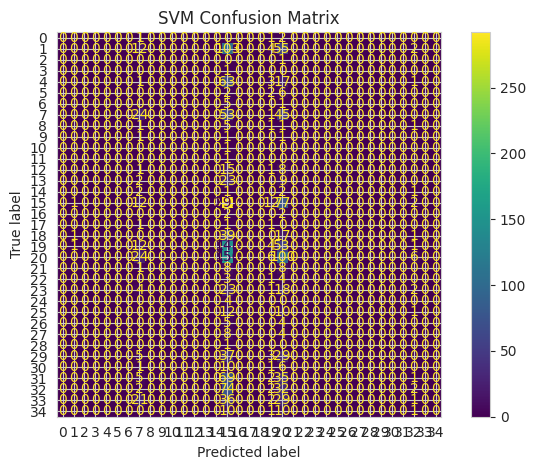

In [124]:
# Confusion matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)

disp_svm = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
   # display_labels=label_encoder.classes_
)

disp_svm.plot()
plt.title("SVM Confusion Matrix")
plt.tight_layout()
plt.show()

# Rendimiento del modelo

In [125]:
print(f"Logistic Regression Accuracy: {accuracy_lr:.4f}")
print(f"Decision Tree Accuracy: {accuracy_dt:.4f}")
print(f"Random Forest Accuracy: {accuracy_rf:.4f}")
print(f"SVM Accuracy: {accuracy_svm:.4f}")

Logistic Regression Accuracy: 0.2255
Decision Tree Accuracy: 0.1325
Random Forest Accuracy: 0.2345
SVM Accuracy: 0.2110
